In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.neural_network import neural_network
from algorithms.auxiliares import *

In [2]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'diabetes_trn.csv'), 1)
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'diabetes_tst.csv'), 1)

print(X_train.shape)
print(y_train.shape)

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std

(353, 10)
(353, 1)


In [3]:
model = neural_network(
    layers_config = [(5, 'symmetry sigmoid'), (3, 'symmetry sigmoid'), (1, 'identity')],
    size_input = X_train_norm.shape[1],
    max_epoch=300,
    learning_rate=0.005,
    error_threshold=1e-3)

model.fit(X_train_norm, y_train)

y_pred = model.transform(X_test_norm)

print(model.score(X_test_norm, y_test))

d:\Facultad\Año 4 Cuatri 1\Redes neuronales I\redes_neuronales\algorithms\neural_network.py:70: RuntimeWarning: overflow encountered in exp
  return 2 / (1 + np.exp(-v)) - 1


4095.6534500623015


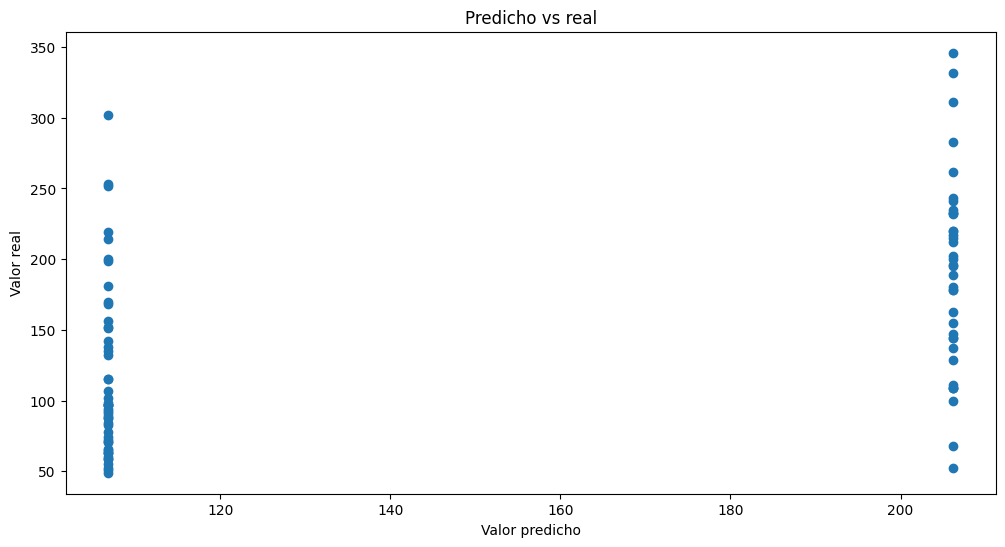

In [6]:
plt.figure(figsize=(12,6))
plt.title("Predicho vs real")
plt.xlabel("Valor predicho")
plt.ylabel("Valor real")
plt.scatter(y_pred, y_test)
plt.show()

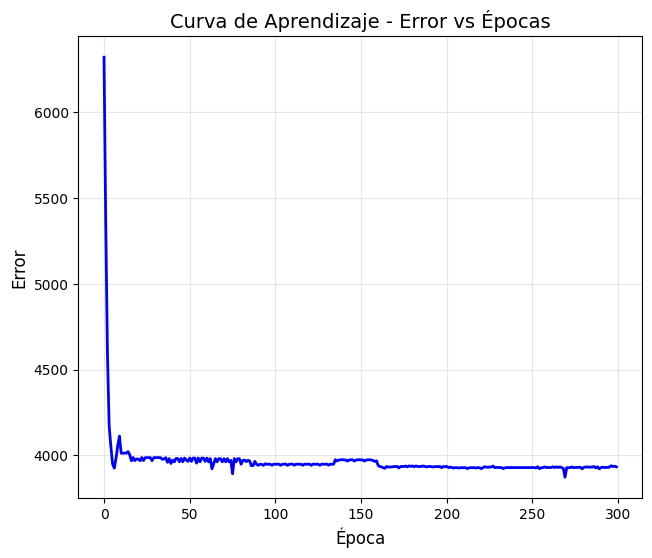

In [5]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.epoch_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)